# Figure S9. UHGV annotation consistency within clusters

In [37]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [38]:
### Download metadata
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/votus_metadata_extended.tsv

In [39]:
### filter UHGV metadata to HQ viruses
hq_votus_pre = (
    pl.read_csv('votus_metadata_extended.tsv', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'uhgv_taxonomy', 'class_name', 'order_name', 'family_name', 'genus_name', 'host_lineage_gtdb_r207', 'crispr_host_lineage_gtdb_r207', 'kmers_host_lineage_gtdb_r207', 'host_prediction_method', 'lifestyle', 'lifestyle_evidence'])

        .rename({'class_name':'Class', 'order_name':'Order', 'family_name':'Family', 'genus_name':'Genus'})
        .with_columns([
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Species'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Genus'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Family'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Order'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Class'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_Phylum'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vOTU-')).then(pl.col('uhgv_taxonomy').str.split(';vOTU-').list[-1]).otherwise(pl.lit(None)).alias('virus_species'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBGEN-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBGEN-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subgenus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vGENUS-')).then(pl.col('uhgv_taxonomy').str.split(';vGENUS-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_genus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBFAM-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subfamily'),
            pl.when(pl.col('uhgv_taxonomy').str.contains('vFAM-')).then(pl.col('uhgv_taxonomy').str.split('vßFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_family'),
        ])
)

hq_votus = (
    pl.read_csv('../figure_1/uhgv_metadata.tsv', separator='\t', ignore_errors=True)[['uhgv_genome', 'genome_length', 'uhgv_votu', 'checkv_completeness', 'checkv_completeness_method', 'viral_confidence']]
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .rename({'uhgv_votu': 'virus_species'})
        .with_columns([
            pl.col('virus_species').str.replace('vOTU-', '')
        ])
        .join(hq_votus_pre, on='virus_species', how='left')
)

complete_genomes = set(
    hq_votus
        .filter(pl.col('checkv_completeness_method').str.contains('TR'))
        ['uhgv_genome']
)

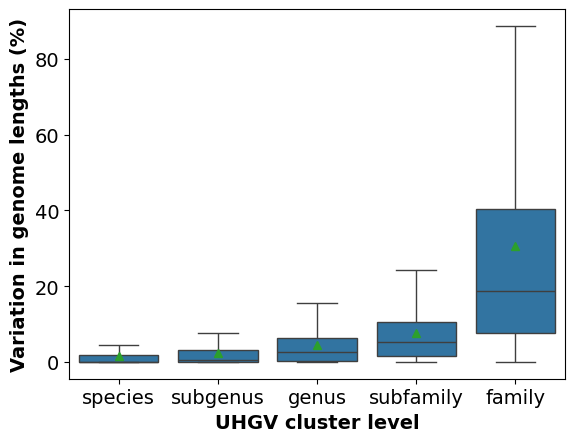

In [40]:
### Genome length variation within UHGV clusters
length_variation_lst = []

complete_hq = (
    hq_votus
        .filter(pl.col('uhgv_genome').is_in(list(complete_genomes)))
        .filter(pl.col('genome_length').is_not_null())
)

for virus_level in ['species', 'subgenus', 'genus', 'subfamily', 'family']:
    length_variation_lst.append(
        complete_hq
            .filter(pl.col(f'virus_{virus_level}').is_not_null())
            .group_by(f'virus_{virus_level}')
            .agg([
                pl.col('genome_length').min().alias('min_genome_length'),
                pl.col('genome_length').max().alias('max_genome_length'),
                pl.col('genome_length').median().alias('median_genome_length'),
                pl.len().alias('cluster_size'),
            ])
            .filter(pl.col('cluster_size') >= 2)
            .with_columns([
                ((pl.col('max_genome_length') - pl.col('min_genome_length'))*100 / pl.col('median_genome_length')).alias('length_variation'),
                pl.lit(virus_level).alias('virus_level'),
            ])
            [['length_variation', 'virus_level']]
    )

plot_df = pl.concat(length_variation_lst)

sns.boxplot(data=plot_df.to_pandas(), y='length_variation', x='virus_level', showmeans=True, showfliers=False)
plt.ylabel('Variation in genome lengths (%)', fontdict={'fontweight': 'bold'})
plt.xlabel('UHGV cluster level', fontdict={'fontweight': 'bold'})
plt.show()

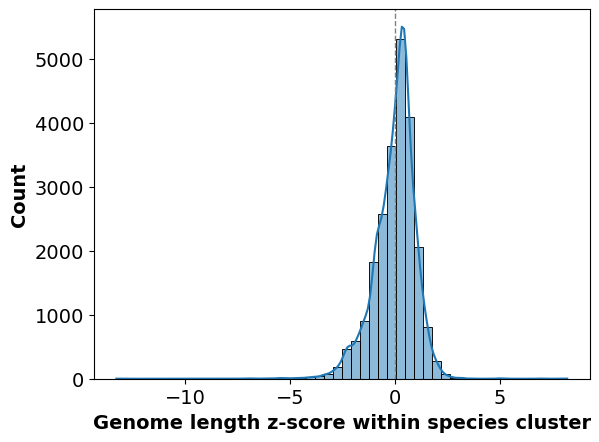

In [41]:
### Genome length z-scores within species-level clusters
species_length_zscores = (
    complete_hq
        .filter(pl.col('virus_species').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_species').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_species').alias('cluster_std'),
            pl.len().over('virus_species').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 15)
        .filter(pl.col('cluster_std') > 0)
        .with_columns(
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
        )
)

sns.histplot(data=species_length_zscores.to_pandas(), x='length_zscore', bins=50, kde=True)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Genome length z-score within species cluster', fontdict={'fontweight': 'bold'})
plt.ylabel('Count', fontdict={'fontweight': 'bold'})
plt.show()

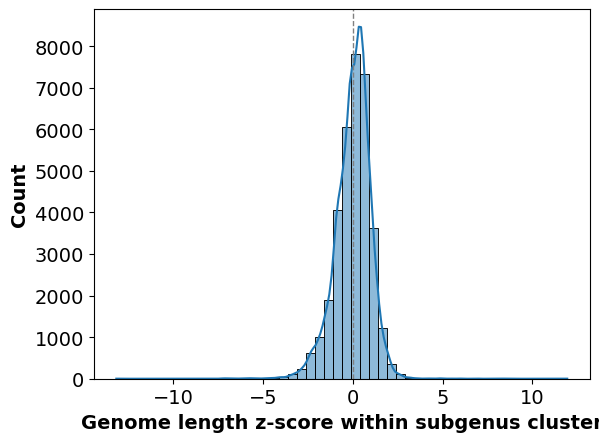

In [42]:
### Genome length z-scores within species-level clusters
species_length_zscores = (
    complete_hq
        .filter(pl.col('virus_subgenus').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_subgenus').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_subgenus').alias('cluster_std'),
            pl.len().over('virus_subgenus').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 15)
        .filter(pl.col('cluster_std') > 0)
        .with_columns(
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
        )
)

sns.histplot(data=species_length_zscores.to_pandas(), x='length_zscore', bins=50, kde=True)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Genome length z-score within subgenus cluster', fontdict={'fontweight': 'bold'})
plt.ylabel('Count', fontdict={'fontweight': 'bold'})
plt.show()

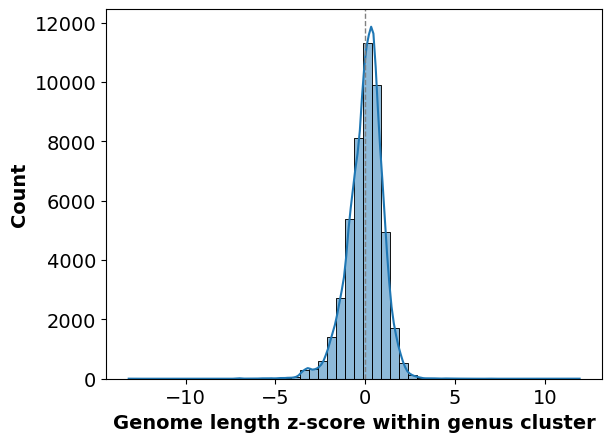

In [43]:
### Genome length z-scores within species-level clusters
species_length_zscores = (
    complete_hq
        .filter(pl.col('virus_genus').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_genus').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_genus').alias('cluster_std'),
            pl.len().over('virus_genus').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 15)
        .filter(pl.col('cluster_std') > 0)
        .with_columns(
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
        )
)

sns.histplot(data=species_length_zscores.to_pandas(), x='length_zscore', bins=50, kde=True)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Genome length z-score within genus cluster', fontdict={'fontweight': 'bold'})
plt.ylabel('Count', fontdict={'fontweight': 'bold'})
plt.show()

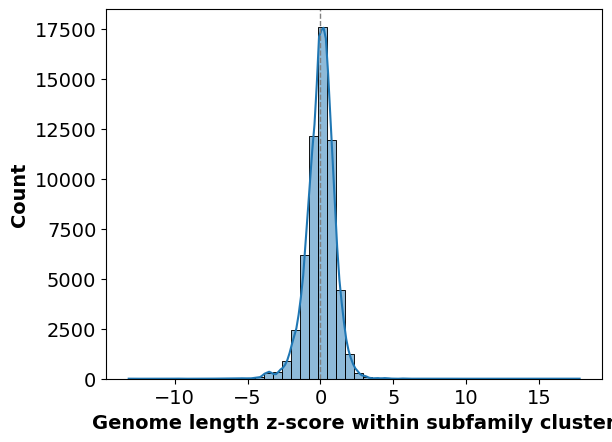

In [44]:
### Genome length z-scores within species-level clusters
species_length_zscores = (
    complete_hq
        .filter(pl.col('virus_subfamily').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_subfamily').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_subfamily').alias('cluster_std'),
            pl.len().over('virus_subfamily').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 15)
        .filter(pl.col('cluster_std') > 0)
        .with_columns(
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
        )
)

sns.histplot(data=species_length_zscores.to_pandas(), x='length_zscore', bins=50, kde=True)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Genome length z-score within subfamily cluster', fontdict={'fontweight': 'bold'})
plt.ylabel('Count', fontdict={'fontweight': 'bold'})
plt.show()

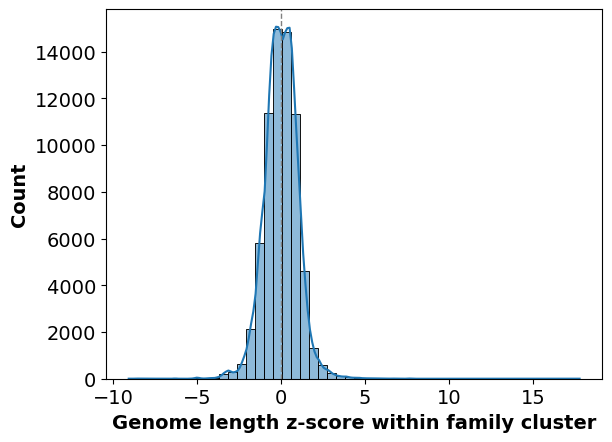

In [45]:
### Genome length z-scores within species-level clusters
species_length_zscores = (
    complete_hq
        .filter(pl.col('virus_family').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_family').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_family').alias('cluster_std'),
            pl.len().over('virus_family').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 15)
        .filter(pl.col('cluster_std') > 0)
        .with_columns(
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
        )
)

sns.histplot(data=species_length_zscores.to_pandas(), x='length_zscore', bins=50, kde=True)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Genome length z-score within family cluster', fontdict={'fontweight': 'bold'})
plt.ylabel('Count', fontdict={'fontweight': 'bold'})
plt.show()

In [46]:
### Percent variation associated with |z| = 3
# pct_variation = abs(genome_length - median_cluster_length) / median_cluster_length * 100
# length_zscore = (genome_length - cluster_mean) / cluster_std

Z_TARGET = 3
Z_WINDOW = (Z_TARGET - 0.05, Z_TARGET + 0.05)

def genome_length_zscore_table(complete_hq, virus_levels=None, min_cluster_size=15, z_target=Z_TARGET):
    if virus_levels is None:
        virus_levels = ['species', 'subgenus', 'genus', 'subfamily', 'family']

    rows = []
    for level in virus_levels:
        cluster_col = f'virus_{level}'
        df = (
            complete_hq
                .filter(pl.col(cluster_col).is_not_null())
                .with_columns([
                    pl.col('genome_length').mean().over(cluster_col).alias('cluster_mean'),
                    pl.col('genome_length').median().over(cluster_col).alias('median_cluster_length'),
                    pl.col('genome_length').std().over(cluster_col).alias('cluster_std'),
                    pl.len().over(cluster_col).alias('cluster_size'),
                ])
                .filter(pl.col('cluster_size') >= min_cluster_size)
                .filter(pl.col('cluster_std') > 0)
                .with_columns([
                    ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore'),
                    (
                        (pl.col('genome_length') - pl.col('median_cluster_length')).abs() * 100
                        / pl.col('median_cluster_length')
                    ).alias('pct_variation_median'),
                    (z_target * pl.col('cluster_std') * 100 / pl.col('cluster_mean')).alias('pct_at_z_cv'),
                ])
                .with_columns([
                    (
                        (pl.col('cluster_mean') + z_target * pl.col('cluster_std') - pl.col('median_cluster_length')).abs() * 100
                        / pl.col('median_cluster_length')
                    ).alias('pct_if_exactly_z_plus'),
                    (
                        (pl.col('cluster_mean') - z_target * pl.col('cluster_std') - pl.col('median_cluster_length')).abs() * 100
                        / pl.col('median_cluster_length')
                    ).alias('pct_if_exactly_z_minus'),
                ])
        )

        near_z = df.filter(pl.col('length_zscore').abs().is_between(*Z_WINDOW))
        ge_z = df.filter(pl.col('length_zscore').abs() >= z_target)
        theoretical_z = pl.concat([
            df.select(pl.col('pct_if_exactly_z_plus').alias('pct')),
            df.select(pl.col('pct_if_exactly_z_minus').alias('pct')),
        ])

        rows.append({
            'virus_level': level,
            'n_genomes': df.height,
            f'n_|z|_{Z_WINDOW[0]}_to_{Z_WINDOW[1]}': near_z.height,
            f'pct_median_|z|_~{z_target}': near_z['pct_variation_median'].median(),
            f'pct_mean_|z|_~{z_target}': near_z['pct_variation_median'].mean(),
            f'pct_median_|z|_>={z_target}': ge_z['pct_variation_median'].median(),
            f'pct_median_theoretical_z=±{z_target}': theoretical_z['pct'].median(),
            f'pct_median_{z_target}*std/mean': df['pct_at_z_cv'].median(),
        })

    return pl.DataFrame(rows)


zscore_pct_summary = genome_length_zscore_table(complete_hq)
print(f'Percent variation vs genome-length z-score |z| = {Z_TARGET} (HQ complete genomes, cluster size >= 15)\n')
print(zscore_pct_summary)

print(f'\nSpecies-level detail (|z| in [{Z_WINDOW[0]}, {Z_WINDOW[1]}]):')
species_df = (
    complete_hq
        .filter(pl.col('virus_species').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_species').alias('cluster_mean'),
            pl.col('genome_length').median().over('virus_species').alias('median_cluster_length'),
            pl.col('genome_length').std().over('virus_species').alias('cluster_std'),
            pl.len().over('virus_species').alias('cluster_size'),
        ])
        .filter(pl.col('cluster_size') >= 20)
        .filter(pl.col('cluster_std') > 0)
        .with_columns([
            ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore'),
            (
                (pl.col('genome_length') - pl.col('median_cluster_length')).abs() * 100
                / pl.col('median_cluster_length')
            ).alias('pct_variation_median'),
        ])
)
species_near_z = species_df.filter(pl.col('length_zscore').abs().is_between(*Z_WINDOW))
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"  p{int(q*100):02d} pct_variation_median: {species_near_z['pct_variation_median'].quantile(q):.2f}%")


Percent variation vs genome-length z-score |z| = 3 (HQ complete genomes, cluster size >= 15)

shape: (5, 8)
┌────────────┬───────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┐
│ virus_leve ┆ n_genomes ┆ n_|z|_2.95 ┆ pct_median ┆ pct_mean_ ┆ pct_media ┆ pct_media ┆ pct_media │
│ l          ┆ ---       ┆ _to_3.05   ┆ _|z|_~3    ┆ |z|_~3    ┆ n_|z|_>=3 ┆ n_theoret ┆ n_3*std/m │
│ ---        ┆ i64       ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ical_z=±3 ┆ ean       │
│ str        ┆           ┆ i64        ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       │
│            ┆           ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       │
╞════════════╪═══════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ species    ┆ 22969     ┆ 30         ┆ 5.55416    ┆ 5.780087  ┆ 6.997674  ┆ 5.268438  ┆ 5.130674  │
│ subgenus   ┆ 34572     ┆ 41         ┆ 4.974432   ┆ 5.240796  ┆ 6.597045  ┆ 5.36964

In [48]:
### Genomes removed by |z| >= 3 filter
Z_FILTER = 2

def count_genomes_removed_by_z(complete_hq, virus_levels=None, min_cluster_size=15, z_filter=Z_FILTER):
    if virus_levels is None:
        virus_levels = ['species', 'subgenus', 'genus', 'subfamily', 'family']

    rows = []
    for level in virus_levels:
        cluster_col = f'virus_{level}'
        df = (
            complete_hq
                .filter(pl.col(cluster_col).is_not_null())
                .with_columns([
                    pl.col('genome_length').mean().over(cluster_col).alias('cluster_mean'),
                    pl.col('genome_length').std().over(cluster_col).alias('cluster_std'),
                    pl.len().over(cluster_col).alias('cluster_size'),
                ])
                .filter(pl.col('cluster_size') >= min_cluster_size)
                .filter(pl.col('cluster_std') > 0)
                .with_columns(
                    ((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std')).alias('length_zscore')
                )
        )
        n_scored = df.height
        n_z_ge = df.filter(pl.col('length_zscore') >= z_filter).height
        n_z_le = df.filter(pl.col('length_zscore') <= -z_filter).height
        n_abs_ge = df.filter(pl.col('length_zscore').abs() >= z_filter).height
        rows.append({
            'virus_level': level,
            'n_scored': n_scored,
            f'n_z>={z_filter}': n_z_ge,
            f'n_z<=-{z_filter}': n_z_le,
            f'n_|z|>={z_filter}': n_abs_ge,
            f'pct_|z|>={z_filter}': 100 * n_abs_ge / n_scored if n_scored else None,
        })

    return pl.DataFrame(rows)


removal_summary = count_genomes_removed_by_z(complete_hq)
print(f'Genomes removed by length z-score filter (cluster size >= 15, HQ complete TR genomes)\n')
print(removal_summary)

# Species-level filter applied to full complete_hq cohort
species_z = (
    complete_hq
        .filter(pl.col('virus_species').is_not_null())
        .with_columns([
            pl.col('genome_length').mean().over('virus_species').alias('cluster_mean'),
            pl.col('genome_length').std().over('virus_species').alias('cluster_std'),
            pl.len().over('virus_species').alias('cluster_size'),
        ])
        .with_columns(
            pl.when((pl.col('cluster_size') >= 15) & (pl.col('cluster_std') > 0))
            .then((pl.col('genome_length') - pl.col('cluster_mean')) / pl.col('cluster_std'))
            .otherwise(None)
            .alias('length_zscore')
        )
)

n_total = complete_hq.height
n_removed = species_z.filter(pl.col('length_zscore').is_not_null() & (pl.col('length_zscore').abs() >= Z_FILTER)).height
n_kept = n_total - n_removed
n_not_scored = species_z.filter(pl.col('length_zscore').is_null()).height

print(f'\nSpecies |z| >= {Z_FILTER} filter on complete_hq (n={n_total:,}):')
print(f'  Removed: {n_removed:,} ({100 * n_removed / n_total:.2f}%)')
print(f'  Kept:    {n_kept:,}')
print(f'  Not scored (cluster < 15 or std = 0): {n_not_scored:,}')


Genomes removed by length z-score filter (cluster size >= 15, HQ complete TR genomes)

shape: (5, 6)
┌─────────────┬──────────┬────────┬─────────┬──────────┬────────────┐
│ virus_level ┆ n_scored ┆ n_z>=2 ┆ n_z<=-2 ┆ n_|z|>=2 ┆ pct_|z|>=2 │
│ ---         ┆ ---      ┆ ---    ┆ ---     ┆ ---      ┆ ---        │
│ str         ┆ i64      ┆ i64    ┆ i64     ┆ i64      ┆ f64        │
╞═════════════╪══════════╪════════╪═════════╪══════════╪════════════╡
│ species     ┆ 22969    ┆ 192    ┆ 949     ┆ 1141     ┆ 4.967565   │
│ subgenus    ┆ 34572    ┆ 375    ┆ 1233    ┆ 1608     ┆ 4.651163   │
│ genus       ┆ 47577    ┆ 515    ┆ 1570    ┆ 2085     ┆ 4.38237    │
│ subfamily   ┆ 58099    ┆ 912    ┆ 1735    ┆ 2647     ┆ 4.556016   │
│ family      ┆ 68737    ┆ 1436   ┆ 1521    ┆ 2957     ┆ 4.301904   │
└─────────────┴──────────┴────────┴─────────┴──────────┴────────────┘

Species |z| >= 2 filter on complete_hq (n=69,705):
  Removed: 1,141 (1.64%)
  Kept:    68,564
  Not scored (cluster < 15 or std 